# Machine Learning Aplicado à Engenharia

## Objetivos de aprendizagem

Ao final desta aula, você deve ser capaz de:

1. explicar a ideia de **modelagem** em aprendizado de máquina;
2. definir **o que é aprendizado de máquina** no contexto de Engenharia Elétrica;
3. distinguir **subajuste** e **sobreajuste**;
4. interpretar a ideia de **correção** em problemas de classificação;
5. compreender o **dilema viés-variância**;
6. reconhecer o papel da **extração e seleção de características**.


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import mean_squared_error

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 320,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)

COLORS = {
    "blue": "#2563eb",
    "cyan": "#0891b2",
    "orange": "#ea580c",
    "gold": "#f59e0b",
    "green": "#16a34a",
    "gray": "#64748b",
    "dark": "#0f172a",
}

rng = np.random.default_rng(42)


def save_figure(fig, filename, caption=None, bottom=0.14):
    if caption:
        fig.subplots_adjust(bottom=bottom)
        fig.text(0.5, 0.02, caption, ha="center", va="bottom", fontsize=9, color="#334155", wrap=True)
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path

## 1. Cenário analisado

Desejamos **detectar falhas em um motor de indução** usando sinais de **corrente**, **vibração** e **temperatura**.

Os sinais são ruidosos e mudam com carga e ambiente. Nem sempre há um modelo físico completo para a decisão. Em muitos casos, precisamos transformar dados em **diagnóstico**, **previsão** ou **alarme**.

**Pergunta central:** como aprender padrões úteis sem apenas decorar o conjunto de treino?


## 2. Modelagem Matemática

Modelar é representar um sistema real por meio de uma abstração matemática.

Em aprendizado de máquina, buscamos uma função que relacione as variáveis de entrada com a saída estimada:

$$ \hat{y} = f_\theta(x) $$

onde:

- $$ x = [x_1, x_2, \dots, x_n]^T $$ 

é o vetor de entrada, formado por uma ou mais variáveis do problema;
- cada componente $x_i$ pode representar temperatura, tensão, corrente, frequência ou outra característica observada;
- $f_\theta$ é um modelo matemático parametrizado;
- $\theta$ é o conjunto de parâmetros ajustados durante o treinamento;
- $\hat{y}$ é a saída estimada pelo modelo;
- $y$ é a saída real ou valor de referência.

O critério de avaliação compara $\hat{y}$ com $y$ usando métricas apropriadas ao problema.

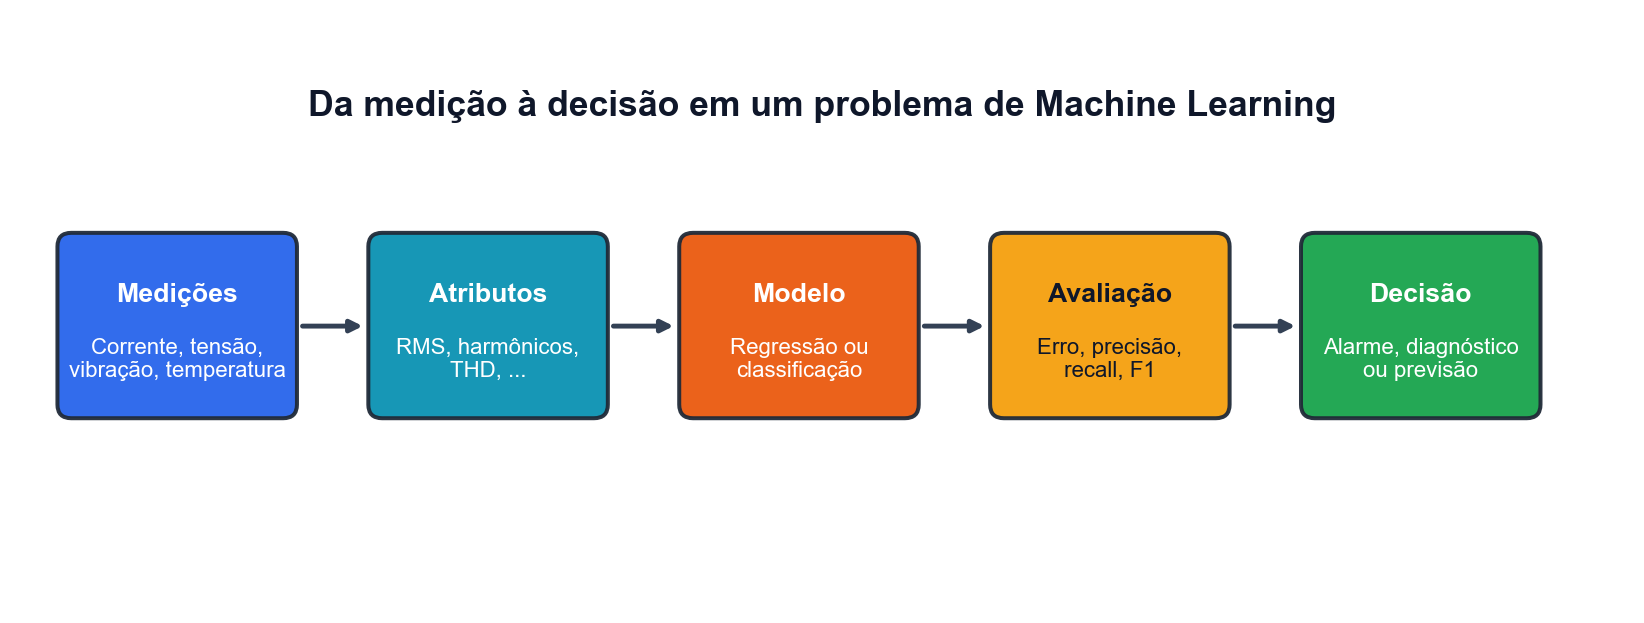

In [45]:
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5.2)
ax.axis("off")

steps = [
    (0.4, COLORS["blue"], "Medições", "Corrente, tensão,\nvibração, temperatura"),
    (3.1, COLORS["cyan"], "Atributos", "RMS, harmônicos,\nTHD, ..."),
    (5.8, COLORS["orange"], "Modelo", "Regressão ou\nclassificação"),
    (8.5, COLORS["gold"], "Avaliação", "Erro, precisão,\nrecall, F1"),
    (11.2, COLORS["green"], "Decisão", "Alarme, diagnóstico\nou previsão"),
]

for x0, color, title, body in steps:
    box = patches.FancyBboxPatch(
        (x0, 1.7),
        2.0,
        1.55,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor=color,
        edgecolor="#1f2937",
        linewidth=1.8,
        alpha=0.94,
    )
    ax.add_patch(box)
    text_color = COLORS["dark"] if color == COLORS["gold"] else "white"
    ax.text(x0 + 1.0, 2.75, title, ha="center", va="center", fontsize=12, fontweight="bold", color=text_color)
    ax.text(x0 + 1.0, 2.18, body, ha="center", va="center", fontsize=10, color=text_color)

for start, end in zip([2.45, 5.15, 7.85, 10.55], [3.05, 5.75, 8.45, 11.15]):
    ax.annotate("", xy=(end, 2.47), xytext=(start, 2.47), arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#334155"))

ax.text(
    7.0,
    4.4,
    "Da medição à decisão em um problema de Machine Learning",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color=COLORS["dark"],
)

path_fig1 = save_figure(fig, "01_modelagem_pipeline.png", caption="", bottom=0.20)
plt.show()


## 3. O que é Aprendizado de Máquina?

Aprendizado de máquina é o estudo de modelos que **aprendem padrões a partir de dados**.

Em vez de programar explicitamente todas as regras do problema, usamos dados para ajustar os parâmetros do modelo. O objetivo não é apenas reproduzir bem os dados já observados, mas **generalizar**, isto é, produzir boas respostas para novos dados.

### Quando isso é útil em Engenharia?

- quando o fenômeno é complexo;
- quando o modelo físico é incompleto;
- quando precisamos de uma aproximação para decisão em tempo real.


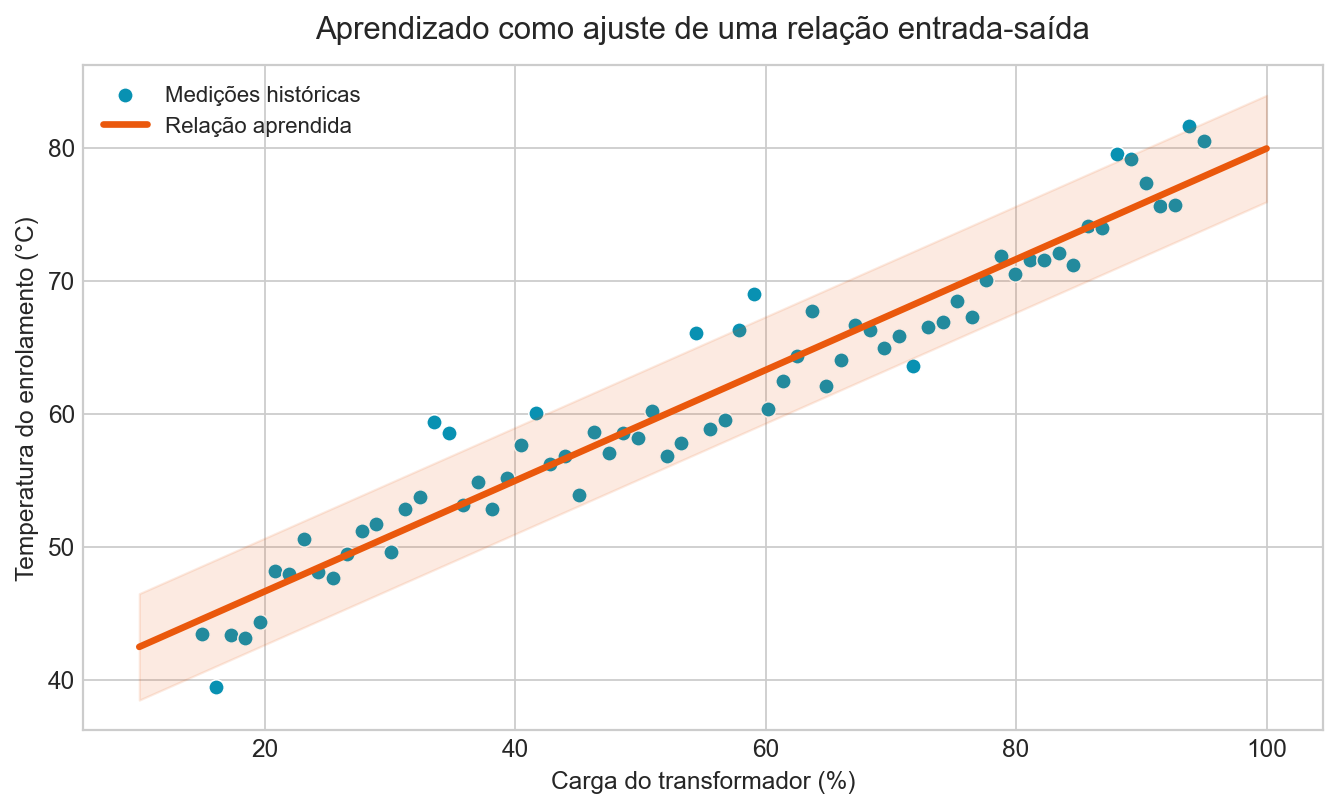

In [7]:

carga = np.linspace(15, 95, 70)
temperatura = 28 + 0.6 * carga + 6 * np.sin(carga / 18) + rng.normal(0, 2.2, size=carga.size)

coef_linear = np.polyfit(carga, temperatura, 1)
x_grid = np.linspace(10, 100, 200)
y_grid = np.polyval(coef_linear, x_grid)

fig, ax = plt.subplots(figsize=(10, 5.4))
ax.scatter(carga, temperatura, color=COLORS["cyan"], s=48, edgecolor="white", linewidth=0.7, label="Medições históricas")
ax.plot(x_grid, y_grid, color=COLORS["orange"], linewidth=3, label="Relação aprendida")
ax.fill_between(x_grid, y_grid - 4, y_grid + 4, color=COLORS["orange"], alpha=0.12)
ax.set_xlabel("Carga do transformador (%)")
ax.set_ylabel("Temperatura do enrolamento (°C)")
ax.set_title("Aprendizado como ajuste de uma relação entrada-saída", pad=12)
ax.legend(frameon=False, loc="upper left")

path_fig2 = save_figure(fig, "02_aprendizado_exemplos.png", caption="", bottom=0.16)
plt.show()


## 4. Subajuste e sobreajuste

### Viés e variância

**Viés** é o erro causado por hipóteses muito simplificadoras no modelo. Um modelo com alto viés tende a não capturar adequadamente o comportamento real dos dados.

**Variância** é a sensibilidade do modelo a pequenas variações no conjunto de treino. Um modelo com alta variância se ajusta demais aos dados vistos e perde capacidade de generalização.


### Subajuste e sobreajuste

**Subajuste**

- modelo simples demais;
- alto viés;
- perde a estrutura do problema;
- erro alto até em treino.

**Sobreajuste**

- modelo complexo demais;
- alta variância;
- ajusta ruído do treino;
- falha ao generalizar.

**Ideia-chave:** um bom modelo aprende o padrão relevante do sistema, não as flutuações acidentais de uma amostra específica.


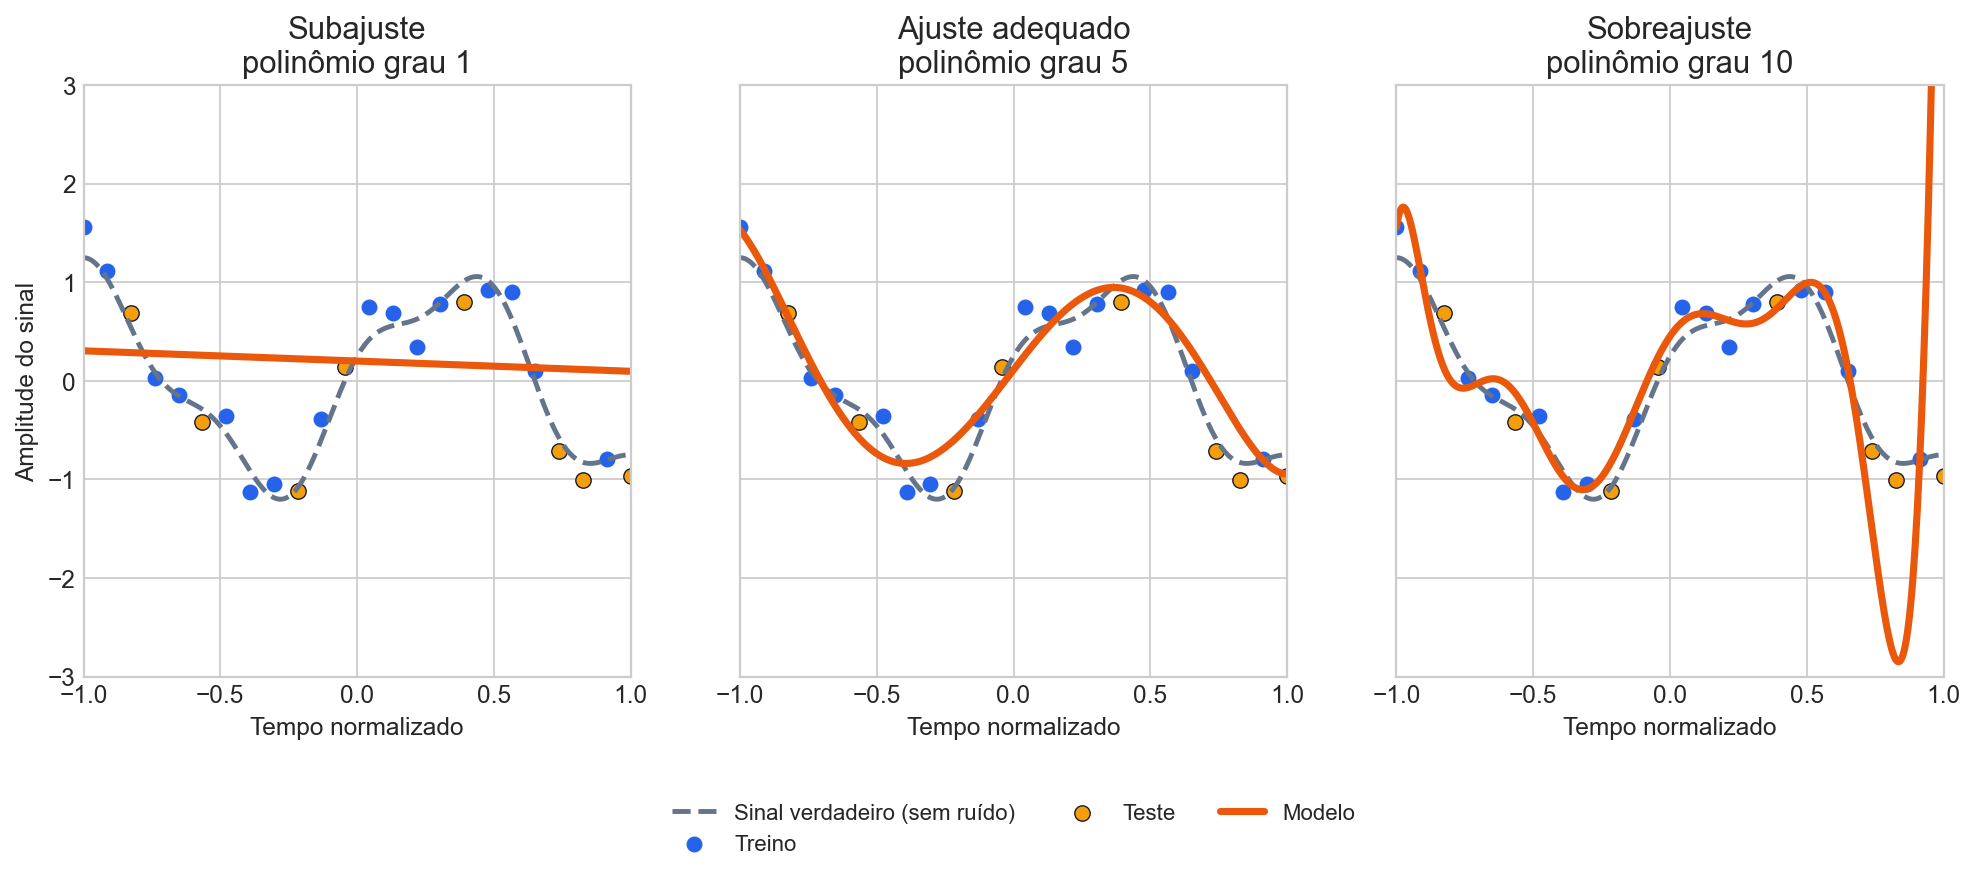

,Regime,Grau,MSE treino,MSE teste
0,Subajuste,1,0.602914,0.740853
1,Ajuste adequado,5,0.059245,0.126932
2,Sobreajuste,10,0.015131,15.999659


In [29]:

f_senoidal = lambda x: np.sin(1.5 * np.pi * x) + 0.25 * np.cos(4 * np.pi * x)

x_poly = np.linspace(-1, 1, 24)
y_poly_real = f_senoidal(x_poly)
y_poly_obs = y_poly_real + rng.normal(0, 0.18, size=x_poly.size)

idx = np.arange(x_poly.size)
rng_poly = np.random.default_rng(7)
rng_poly.shuffle(idx)
train_idx = np.sort(idx[:16])
test_idx = np.sort(idx[16:])

x_train_polyfit = x_poly[train_idx]
y_train_polyfit = y_poly_obs[train_idx]
x_test_polyfit = x_poly[test_idx]
y_test_polyfit = y_poly_obs[test_idx]

x_dense_polyfit = np.linspace(-1, 1, 500)
y_dense_polyfit = f_senoidal(x_dense_polyfit)

graus = [1, 5, 10]
nomes = ["Subajuste", "Ajuste adequado", "Sobreajuste"]
ajustes_polyfit = []

for grau, nome in zip(graus, nomes):
    coef = np.polyfit(x_train_polyfit, y_train_polyfit, grau)
    ajustes_polyfit.append(
        {
            "nome": nome,
            "grau": grau,
            "coef": coef,
            "pred_dense": np.polyval(coef, x_dense_polyfit),
            "mse_treino": mean_squared_error(y_train_polyfit, np.polyval(coef, x_train_polyfit)),
            "mse_teste": mean_squared_error(y_test_polyfit, np.polyval(coef, x_test_polyfit)),
        }
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, ajuste in zip(axes, ajustes_polyfit):
    ax.plot(x_dense_polyfit, y_dense_polyfit, "--", color=COLORS["gray"], linewidth=2.2, label="Sinal verdadeiro (sem ruído)")
    ax.scatter(x_train_polyfit, y_train_polyfit, color=COLORS["blue"], s=38, label="Treino")
    ax.scatter(x_test_polyfit, y_test_polyfit, color=COLORS["gold"], s=48, edgecolor=COLORS["dark"], linewidth=0.6, label="Teste")
    ax.plot(x_dense_polyfit, ajuste["pred_dense"], color=COLORS["orange"], linewidth=3.2, label="Modelo")
    ax.set_title(f"{ajuste['nome']}\npolinômio grau {ajuste['grau']}")
    ax.set_xlabel("Tempo normalizado")
    ax.set_xlim(-1, 1)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel("Amplitude do sinal")
axes[1].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
caption = "Figura 3. Três regimes de complexidade do modelo: subajuste, ajuste adequado e sobreajuste ao tentar representar um sinal com ruído."
path_fig3 = save_figure(fig, "03_subajuste_sobreajuste.png", caption="", bottom=0.22)
plt.show()

pd.DataFrame(
    [{"Regime": a["nome"], "Grau": a["grau"], "MSE treino": a["mse_treino"], "MSE teste": a["mse_teste"]} for a in ajustes_polyfit]
)


### Leitura da figura

- **Subajuste:** a hipótese é pobre demais para capturar a curvatura do fenômeno.
- **Ajuste adequado:** o modelo acompanha a tendência dominante sem oscilar demais.
- **Sobreajuste:** a curva segue detalhes espúrios que pertencem ao ruído do conjunto de treino.

Em sinais de corrente ou vibração, um modelo superajustado pode parecer excelente em bancada e falhar quando o equipamento muda de carga, ambiente ou regime.


## 5. Viés-variância

O dilema viés-variância resume um compromisso importante:

- aumentar a complexidade costuma **reduzir viés**;
- aumentar a complexidade costuma **elevar variância**;
- boa generalização normalmente aparece em uma **faixa intermediária** de complexidade.


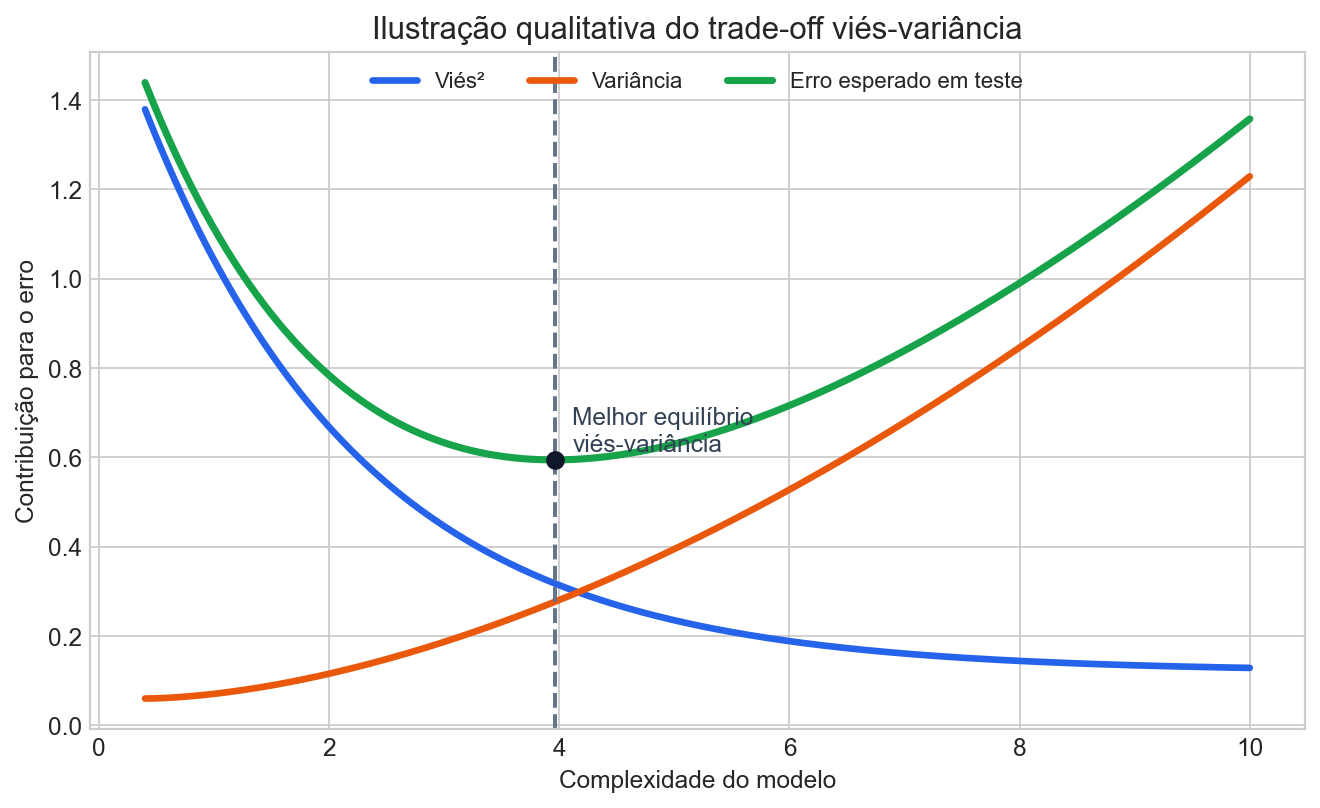

In [32]:

complexidade = np.linspace(0.4, 10, 300)
vies2 = 1.55 * np.exp(-0.52 * complexidade) + 0.12
variancia = 0.06 + 0.025 * (complexidade - 0.4) ** 1.7
erro_teste = vies2 + variancia
melhor_idx = np.argmin(erro_teste)

fig, ax = plt.subplots(figsize=(9.8, 5.5))
ax.plot(complexidade, vies2, color=COLORS["blue"], linewidth=3, label="Viés²")
ax.plot(complexidade, variancia, color=COLORS["orange"], linewidth=3, label="Variância")
ax.plot(complexidade, erro_teste, color=COLORS["green"], linewidth=3.2, label="Erro esperado em teste")
ax.axvline(complexidade[melhor_idx], color=COLORS["gray"], linestyle="--", linewidth=1.8)
ax.scatter([complexidade[melhor_idx]], [erro_teste[melhor_idx]], color=COLORS["dark"], s=55, zorder=5)
ax.text(
    complexidade[melhor_idx] + 0.15,
    erro_teste[melhor_idx] + 0.02,
    "Melhor equilíbrio\nviés-variância",
    color="#334155",
)
ax.set_xlabel("Complexidade do modelo")
ax.set_ylabel("Contribuição para o erro")
ax.set_title("Ilustração qualitativa do trade-off viés-variância")
ax.legend(frameon=False, loc="upper center", ncol=3)

path_fig5 = save_figure(fig, "05_vies_variancia.png", caption="", bottom=0.16)
plt.show()

### Como reduzir viés ou variância?

**Para reduzir viés**

- usar modelo mais expressivo;
- construir características mais informativas;
- melhorar a representação do fenômeno.

**Para reduzir variância**

- obter mais dados;
- reduzir complexidade;
- aplicar regularização;
- validar o modelo em dados não vistos.


## 6. Correção

Em problemas de classificação, não basta saber apenas quantos acertos o modelo teve. Também precisamos entender **quais tipos de erro** ele comete.

Em manutenção preditiva, deixar de detectar uma falha real costuma ser mais grave do que emitir um falso alarme. Por isso, a noção de correção precisa ser analisada com mais cuidado.


### Resultados possíveis em classificação binária

Considerando a classe positiva como **falha**, temos quatro resultados possíveis:

- **VP** (verdadeiro positivo): o modelo previu falha e a condição real também era falha;
- **FP** (falso positivo): o modelo previu falha, mas a condição real era normal;
- **FN** (falso negativo): o modelo previu normal, mas a condição real era falha;
- **VN** (verdadeiro negativo): o modelo previu normal e a condição real também era normal.


### Métricas para avaliação em classificação

As métricas mais comuns são:

$ \text{Precisão} = \frac{VP}{VP + FP}$

Entre todos os casos classificados como falha, quantos eram realmente falhas.

$ \text{Recall} = \frac{VP}{VP + FN}$

Entre todas as falhas reais, quantas foram corretamente detectadas.

$ F_1 = 2 \cdot \frac{\text{Precisão} \cdot \text{Recall}}{\text{Precisão} + \text{Recall}}$

O **$F_1$** busca equilibrar precisão e recall.


### Acurácia sozinha pode enganar

Quando falhas são raras, prever sempre **normal** pode gerar acurácia aparentemente alta. Isso não significa que o classificador seja útil.

Em Engenharia, a métrica deve refletir o **custo operacional do erro**.


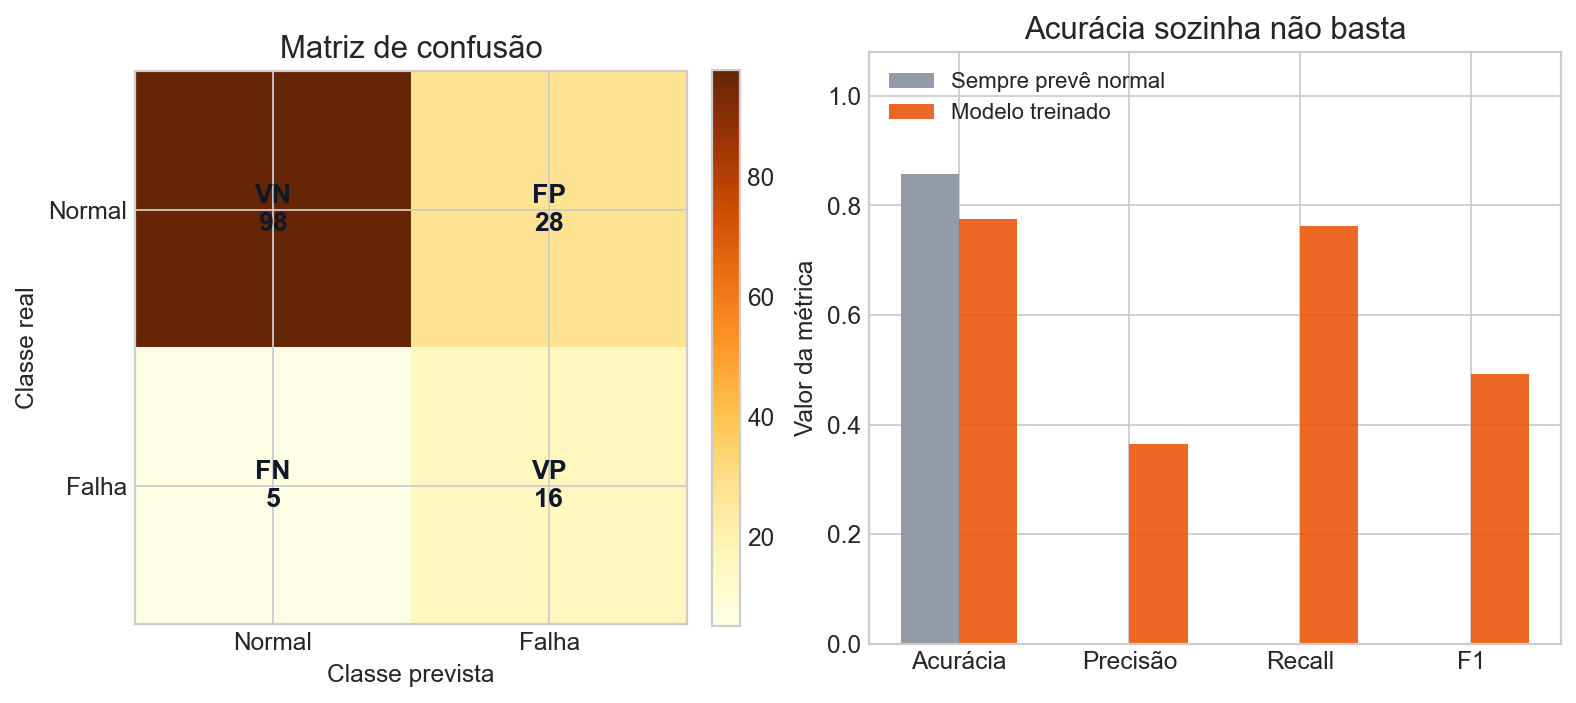

,Estratégia,Acurácia,Precisão,Recall,F1
0,Sempre prevê normal,0.857143,0.000000,0.000000,0.000000
1,Modelo treinado,0.775510,0.363636,0.761905,0.492308


In [35]:
cm = np.array([[98, 28], [5, 16]])
classes = ["Normal", "Falha"]

vp = cm[1, 1]
fp = cm[0, 1]
fn = cm[1, 0]
vn = cm[0, 0]

a_baseline = (vn + fp) / cm.sum()
p_baseline = 0.0
r_baseline = 0.0
f1_baseline = 0.0

a_modelo = (vp + vn) / cm.sum()
p_modelo = vp / (vp + fp)
r_modelo = vp / (vp + fn)
f1_modelo = 2 * p_modelo * r_modelo / (p_modelo + r_modelo)

metric_cols = ["Acurácia", "Precisão", "Recall", "F1"]
baseline_vals = [a_baseline, p_baseline, r_baseline, f1_baseline]
trained_vals = [a_modelo, p_modelo, r_modelo, f1_modelo]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [1.05, 1.2]})

im = axes[0].imshow(cm, cmap="YlOrBr")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        label = [["VN", "FP"], ["FN", "VP"]][i][j]
        axes[0].text(j, i, f"{label}\n{cm[i, j]}", ha="center", va="center", fontsize=12, fontweight="bold", color=COLORS["dark"])
axes[0].set_xticks([0, 1], classes)
axes[0].set_yticks([0, 1], classes)
axes[0].set_xlabel("Classe prevista")
axes[0].set_ylabel("Classe real")
axes[0].set_title("Matriz de confusão")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

x = np.arange(len(metric_cols))
width = 0.34
axes[1].bar(x - width / 2, baseline_vals, width=width, color="#8d96a3", alpha=0.95, label="Sempre prevê normal")
axes[1].bar(x + width / 2, trained_vals, width=width, color=COLORS["orange"], alpha=0.9, label="Modelo treinado")
axes[1].set_xticks(x, metric_cols)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel("Valor da métrica")
axes[1].set_title("Acurácia sozinha não basta")
axes[1].legend(frameon=False, loc="upper left")

path_fig4 = save_figure(fig, "04_correcao_metricas_v2.png", caption="", bottom=0.16)
plt.show()
pd.DataFrame(
    {
        "Estratégia": ["Sempre prevê normal", "Modelo treinado"],
        "Acurácia": [a_baseline, a_modelo],
        "Precisão": [p_baseline, p_modelo],
        "Recall": [r_baseline, r_modelo],
        "F1": [f1_baseline, f1_modelo],
    }
)


## 7. Extração e seleção de recursos

Em muitos problemas de Engenharia Elétrica, não entregamos o sinal bruto diretamente ao modelo. Primeiro extraímos **recursos** ou **features** que resumem informações importantes.

Exemplos de recursos extraídos de sinais:

- RMS;
- curtose;
- fator de crista;
- energia em bandas de frequência;
- taxa de cruzamento por zero;
- harmônicos e distorção total.

Depois disso, podemos fazer **seleção de recursos**, mantendo apenas os atributos mais informativos para a tarefa.


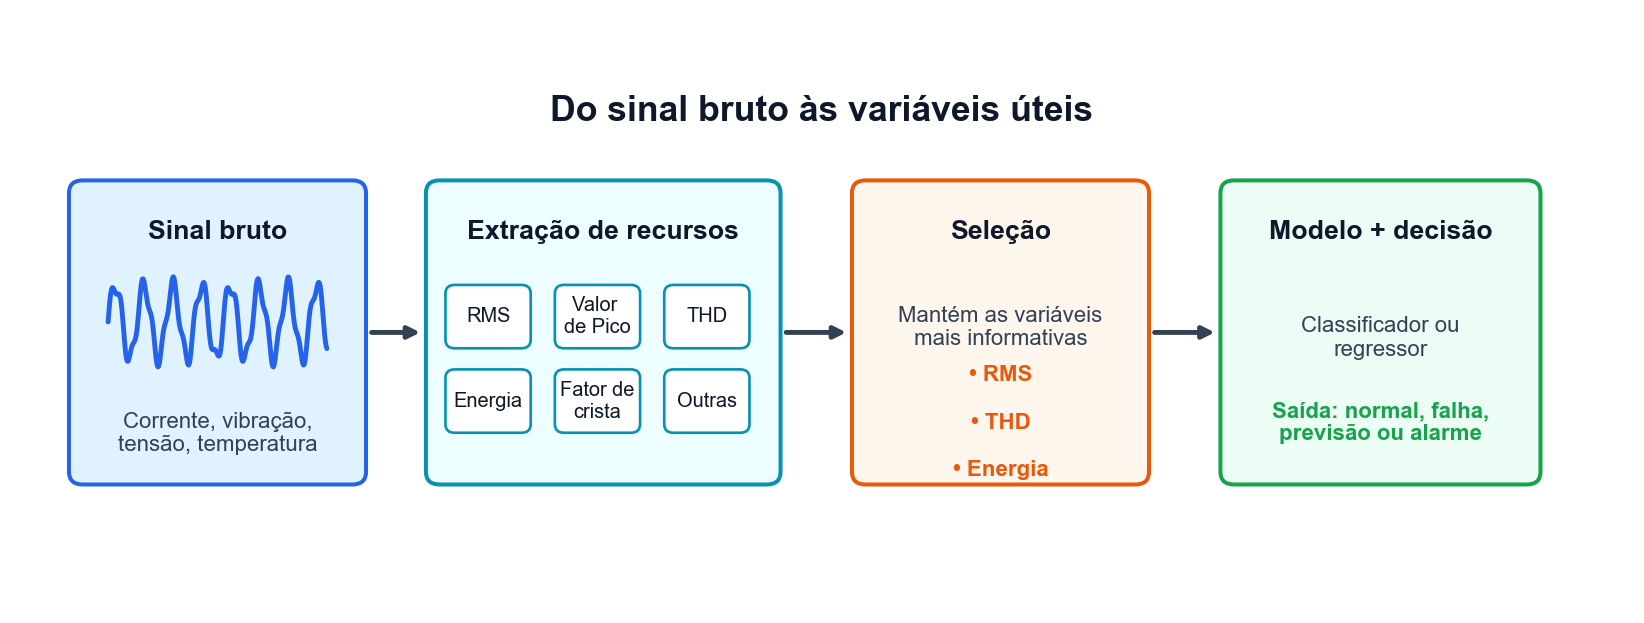

In [39]:

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5.6)
ax.axis("off")

raw_box = patches.FancyBboxPatch((0.5, 1.2), 2.5, 2.8, boxstyle="round,pad=0.04,rounding_size=0.12", facecolor="#e0f2fe", edgecolor=COLORS["blue"], linewidth=1.8)
feat_box = patches.FancyBboxPatch((3.6, 1.2), 3.0, 2.8, boxstyle="round,pad=0.04,rounding_size=0.12", facecolor="#ecfeff", edgecolor=COLORS["cyan"], linewidth=1.8)
select_box = patches.FancyBboxPatch((7.3, 1.2), 2.5, 2.8, boxstyle="round,pad=0.04,rounding_size=0.12", facecolor="#fff7ed", edgecolor=COLORS["orange"], linewidth=1.8)
model_box = patches.FancyBboxPatch((10.5, 1.2), 2.7, 2.8, boxstyle="round,pad=0.04,rounding_size=0.12", facecolor="#ecfdf5", edgecolor=COLORS["green"], linewidth=1.8)
for box in [raw_box, feat_box, select_box, model_box]:
    ax.add_patch(box)

xs = np.linspace(0.8, 2.7, 300)
ys = 2.7 + 0.35 * np.sin(8 * np.pi * (xs - 0.8)) + 0.08 * np.sin(22 * np.pi * (xs - 0.8))
ax.plot(xs, ys, color=COLORS["blue"], linewidth=2.2)
ax.text(1.75, 3.55, "Sinal bruto", ha="center", va="center", fontsize=12, fontweight="bold", color=COLORS["dark"])
ax.text(1.75, 1.65, "Corrente, vibração,\ntensão, temperatura", ha="center", va="center", fontsize=10, color="#334155")

ax.text(5.1, 3.55, "Extração de recursos", ha="center", va="center", fontsize=12, fontweight="bold", color=COLORS["dark"])
feature_labels = ["RMS", "Valor \nde Pico", "THD", "Energia", "Fator de\ncrista", "Outras"]
feature_positions = [(4.1, 2.75), (5.05, 2.75), (6.0, 2.75), (4.1, 1.95), (5.05, 1.95), (6.0, 1.95)]
for (xp, yp), label in zip(feature_positions, feature_labels):
    chip = patches.FancyBboxPatch((xp - 0.35, yp - 0.28), 0.7, 0.56, boxstyle="round,pad=0.02,rounding_size=0.08", facecolor="white", edgecolor=COLORS["cyan"], linewidth=1.2)
    ax.add_patch(chip)
    ax.text(xp, yp, label, ha="center", va="center", fontsize=9, color=COLORS["dark"])

ax.text(8.55, 3.55, "Seleção", ha="center", va="center", fontsize=12, fontweight="bold", color=COLORS["dark"])
ax.text(8.55, 2.65, "Mantém as variáveis\nmais informativas", ha="center", va="center", fontsize=10, color="#334155")
for yp, label in zip([2.2, 1.75, 1.3], ["RMS", "THD", "Energia"]):
    ax.text(8.55, yp, f"• {label}", ha="center", va="center", fontsize=10, color=COLORS["orange"], fontweight="bold")

ax.text(11.85, 3.55, "Modelo + decisão", ha="center", va="center", fontsize=12, fontweight="bold", color=COLORS["dark"])
ax.text(11.85, 2.55, "Classificador ou\nregressor", ha="center", va="center", fontsize=10, color="#334155")
ax.text(11.85, 1.75, "Saída: normal, falha,\nprevisão ou alarme", ha="center", va="center", fontsize=10, color=COLORS["green"], fontweight="bold")

for start, end in [((3.05, 2.6), (3.55, 2.6)), ((6.65, 2.6), (7.25, 2.6)), ((9.85, 2.6), (10.45, 2.6))]:
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", lw=2.2, color="#334155"))

ax.text(7.0, 4.7, "Do sinal bruto às variáveis úteis", ha="center", va="center", fontsize=16, fontweight="bold", color=COLORS["dark"])
caption = "Figura 6. Fluxo de extração e seleção de recursos: do sinal bruto são derivados atributos no tempo e na frequência, dos quais permanecem os mais informativos para classificação."
path_fig6 = save_figure(fig, "06_extracao_selecao_recursos.png", caption="", bottom=0.20)
plt.show()


### Por que a extração de características ajuda?

Uma forma de enxergar isso é comparar dois sinais no domínio do tempo e, em seguida, observar como **características resumidas** tornam a separação mais clara.

No gráfico a seguir, o sinal **normal** é aproximadamente senoidal, enquanto o sinal **com falha/ruído** apresenta distorção, ruído e conteúdo harmônico adicional. À direita, extraímos poucas características e mostramos como elas ajudam a distinguir os regimes de operação.

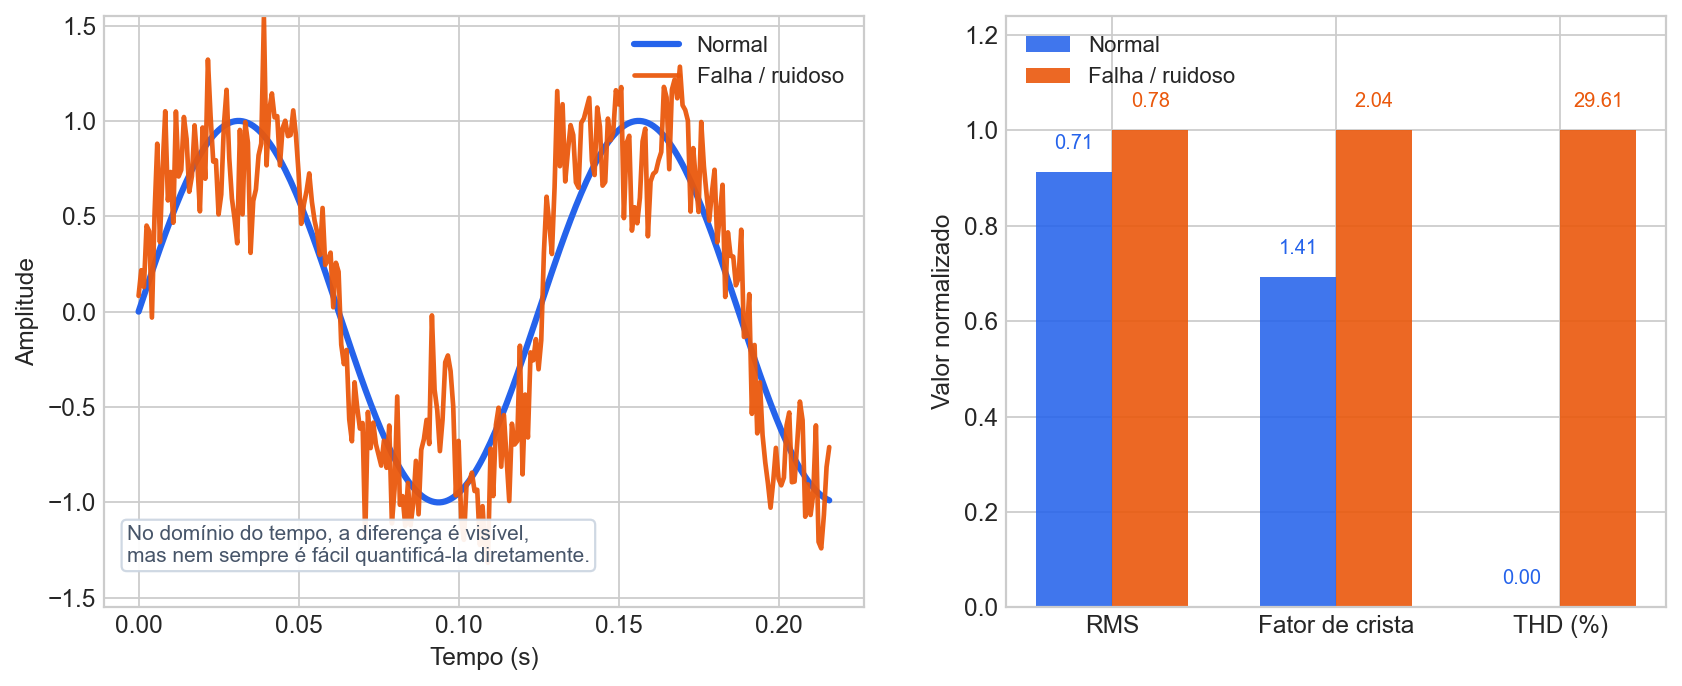

In [44]:
fs = 1200
T = 1.0
n = int(fs * T)
t = np.linspace(0, T, n, endpoint=False)

sinal_normal = 1.0 * np.sin(2 * np.pi * 8 * t)
sinal_falha = (
    1.0 * np.sin(2 * np.pi * 8 * t)
    + 0.30 * np.sin(2 * np.pi * 24 * t)
    + 0.16 * np.sin(2 * np.pi * 55 * t)
    + 0.20 * rng.normal(size=t.size)
)


def rms(x):
    return np.sqrt(np.mean(x**2))


def fator_crista(x):
    return np.max(np.abs(x)) / rms(x)


def thd_percent(x, fs, f0):
    freqs = np.fft.rfftfreq(x.size, d=1 / fs)
    amp = np.abs(np.fft.rfft(x))
    k0 = np.argmin(np.abs(freqs - f0))
    fund = amp[k0]
    harmonic_powers = []
    for k in range(2, 8):
        kk = np.argmin(np.abs(freqs - k * f0))
        harmonic_powers.append(amp[kk] ** 2)
    return 100 * np.sqrt(np.sum(harmonic_powers)) / fund


features_normal = {
    "RMS": rms(sinal_normal),
    "Fator de crista": fator_crista(sinal_normal),
    "THD (%)": thd_percent(sinal_normal, fs, 8),
}
features_falha = {
    "RMS": rms(sinal_falha),
    "Fator de crista": fator_crista(sinal_falha),
    "THD (%)": thd_percent(sinal_falha, fs, 8),
}

labels = list(features_normal.keys())
vals_normal = np.array([features_normal[k] for k in labels], dtype=float)
vals_falha = np.array([features_falha[k] for k in labels], dtype=float)
vals_ref = np.maximum(vals_normal, vals_falha)
vals_normal_scaled = vals_normal / vals_ref
vals_falha_scaled = vals_falha / vals_ref

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.8), gridspec_kw={"width_ratios": [1.15, 1.0]})

# Esquerda: sinais no domínio do tempo
ax = axes[0]
window = slice(0, 260)
ax.plot(t[window], sinal_normal[window], color=COLORS["blue"], linewidth=2.8, label="Normal")
ax.plot(t[window], sinal_falha[window], color=COLORS["orange"], linewidth=2.1, alpha=0.95, label="Falha / ruidoso")
ax.set_xlabel("Tempo (s)")
ax.set_ylabel("Amplitude")
ax.set_ylim(-1.55, 1.55)
ax.legend(frameon=False, loc="upper right")
ax.text(
    0.03,
    0.07,
    "No domínio do tempo, a diferença é visível,\nmas nem sempre é fácil quantificá-la diretamente.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=9.4,
    color="#475569",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cbd5e1", alpha=0.92),
)

# Direita: características resumidas
ax = axes[1]
x = np.arange(len(labels))
width = 0.34
ax.bar(x - width / 2, vals_normal_scaled, width=width, color=COLORS["blue"], alpha=0.88, label="Normal")
ax.bar(x + width / 2, vals_falha_scaled, width=width, color=COLORS["orange"], alpha=0.90, label="Falha / ruidoso")
ax.set_xticks(x, labels)
ax.set_ylim(0, 1.24)
ax.set_ylabel("Valor normalizado")
ax.legend(frameon=False, loc="upper left")

for i, (vn, vf) in enumerate(zip(vals_normal, vals_falha)):
    ax.text(i - width / 2, vals_normal_scaled[i] + 0.04, f"{vn:.2f}", ha="center", va="bottom", fontsize=9, color=COLORS["blue"])
    ax.text(i + width / 2, vals_falha_scaled[i] + 0.04, f"{vf:.2f}", ha="center", va="bottom", fontsize=9, color=COLORS["orange"])

path_fig7 = save_figure(fig, "07_extracao_caracteristicas_intuicao.png", caption="", bottom=0.18)
plt.show()

### Impacto prático

A qualidade dos recursos influencia diretamente a capacidade de separação entre classes ou a qualidade de uma regressão.

No contexto de Engenharia Elétrica:

- bons recursos podem facilitar a identificação de falhas em rolamentos, curtos entre espiras ou desalinhamentos;
- recursos mal escolhidos podem esconder o padrão relevante;
- seleção de recursos ajuda a reduzir ruído, custo computacional e risco de sobreajuste.


## 8. Exercícios sugeridos

1. **Estudo de subajuste e sobreajuste**: altere o grau do polinômio no exemplo com `np.polyfit` e descreva em que faixa o erro de teste é menor.
2. **Custo do erro**: explique por que, em manutenção preditiva, um falso negativo pode ser mais grave que um falso positivo.
3. **Seleção de recursos**: suponha dez atributos extraídos de sinais de corrente. Proponha um critério para escolher apenas três para um sistema embarcado com limitação de memória.
4. **Previsão de demanda**: construa um pequeno conjunto sintético com temperatura ambiente, hora do dia e carga histórica para estimar demanda elétrica. Discuta como identificar viés e variância no modelo.
5. **Diagnóstico com sinais**: descreva quais atributos no tempo e na frequência poderiam ajudar a diferenciar operação normal e falha em um inversor.


## 9. Referência-base

A organização conceitual desta aula segue o conteúdo do material expositivo e a base bibliográfica indicada para o tópico.

- Joel Grus, *Data Science do Zero*.
- Capítulo 11: **Aprendizado de Máquina**.
